# **Lab 4 a**


#Training a Decision Tree Classifier

Get the iris dataset and train a classifier using a decision tree. Use scikit-learn’s DecisionTreeClassifier.

Note: use the dataset provided by sklearn datasets (check documentation)

# make a new observation and predict observation’s class

observation = [[5, 4, 3, 2]]

view predicted class probabilities of the observation
New Section
model.predict_proba(observation)

Finally, check the documentation of pydotplus library and write the visualisation (‘tree’) in PNG format.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn import tree
import pydotplus
from IPython.display import Image


In [ ]:
# Load iris dataset
iris = load_iris()
df_4a = pd.DataFrame(iris.data, columns=iris.feature_names)
df_4a['target'] = iris.target

# Display the first few rows
df_4a.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
X = df_4a.drop("target", axis=1)
y = df_4a["target"]

# Split data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Train the Decision Tree model
model_4a = DecisionTreeClassifier()
model_4a.fit(X_train, y_train)


DecisionTreeClassifier()

In [ ]:
observation = [[5, 4, 3, 2]]
predicted_class_4a = model_4a.predict(observation)
predicted_proba_4a = model_4a.predict_proba(observation)

print("Predicted Class:", predicted_class_4a)
print("Predicted Class Probabilities:", predicted_proba_4a)


Predicted Class: [2]
Predicted Class Probabilities: [[0. 0. 1.]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Predictions on the test set
y_pred = model_4a.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



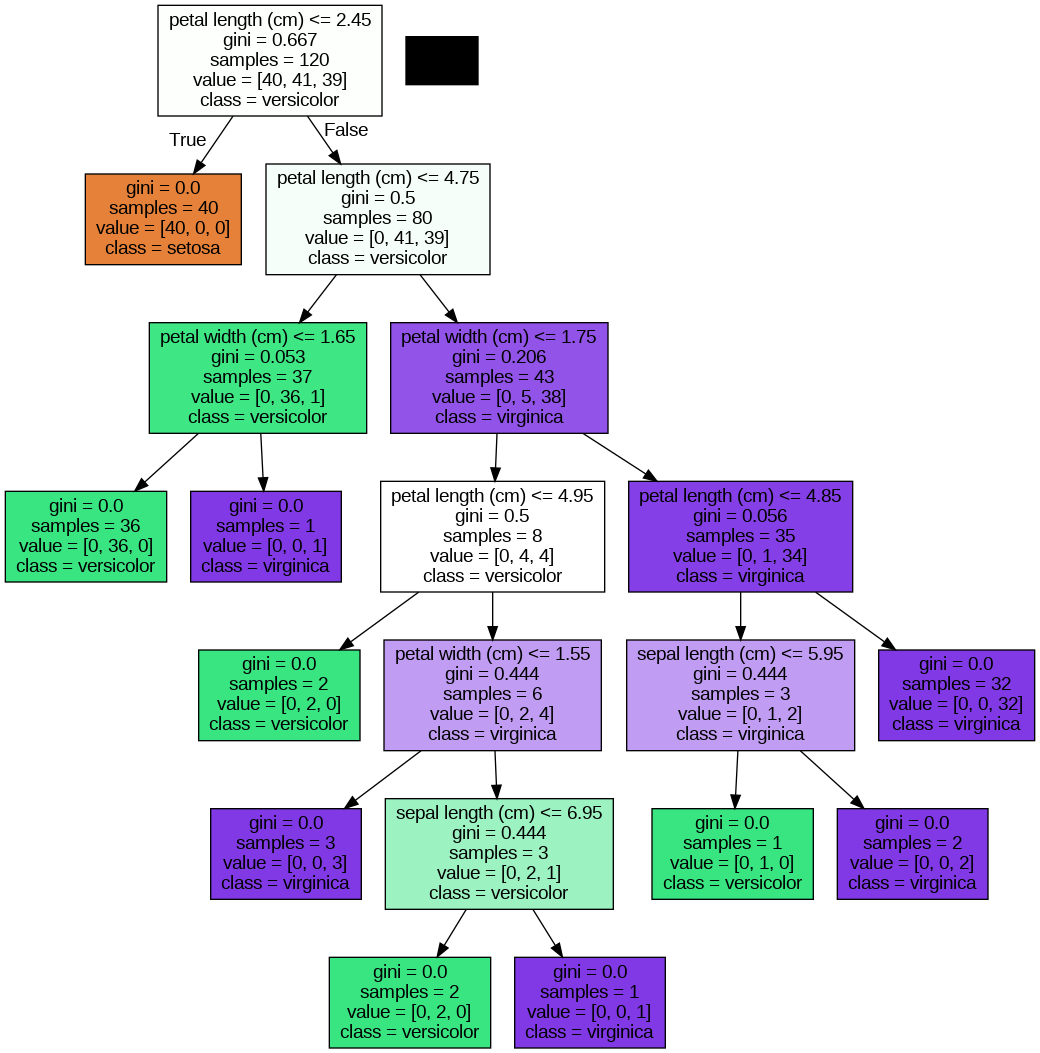

In [ ]:
# Visualizing the Decision Tree
dot_data_4a = tree.export_graphviz(model_4a, out_file=None, feature_names=iris.feature_names, class_names=iris.target_names,
                           filled=True)

graph_4a = pydotplus.graph_from_dot_data(dot_data_4a)

# Displaying the tree image
Image(graph_4a.create_png())

# **Lab 4b**

Train a classification model using a ‘forest’ of randomised decisiontrees.Using the same dataset as in Lab 4a (iris)

#create a Random Forest Classifier

Again, make a new observation and predict observation’s
classobservation = [[5, 4, 3, 2]]

#view predicted class probabilities of the observationmodel.

predict_proba(observation)

Finally, check the documentation of pydotplus library and write the visualisation (‘tree’)in PDF format.


In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
rf_model_4b = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_4b.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
rf_predicted_class_4b = rf_model_4b.predict(observation)
rf_predicted_proba_4b = rf_model_4b.predict_proba(observation)

print("Random Forest Predicted Class:", rf_predicted_class_4b)
print("Random Forest Predicted Class Probabilities:", rf_predicted_proba_4b)


Random Forest Predicted Class: [1]
Random Forest Predicted Class Probabilities: [[0.03 0.54 0.43]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Predictions on the test set
rf_y_pred_4b = rf_model_4b.predict(X_test)

# Classification Report
print(classification_report(y_test, rf_y_pred_4b))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



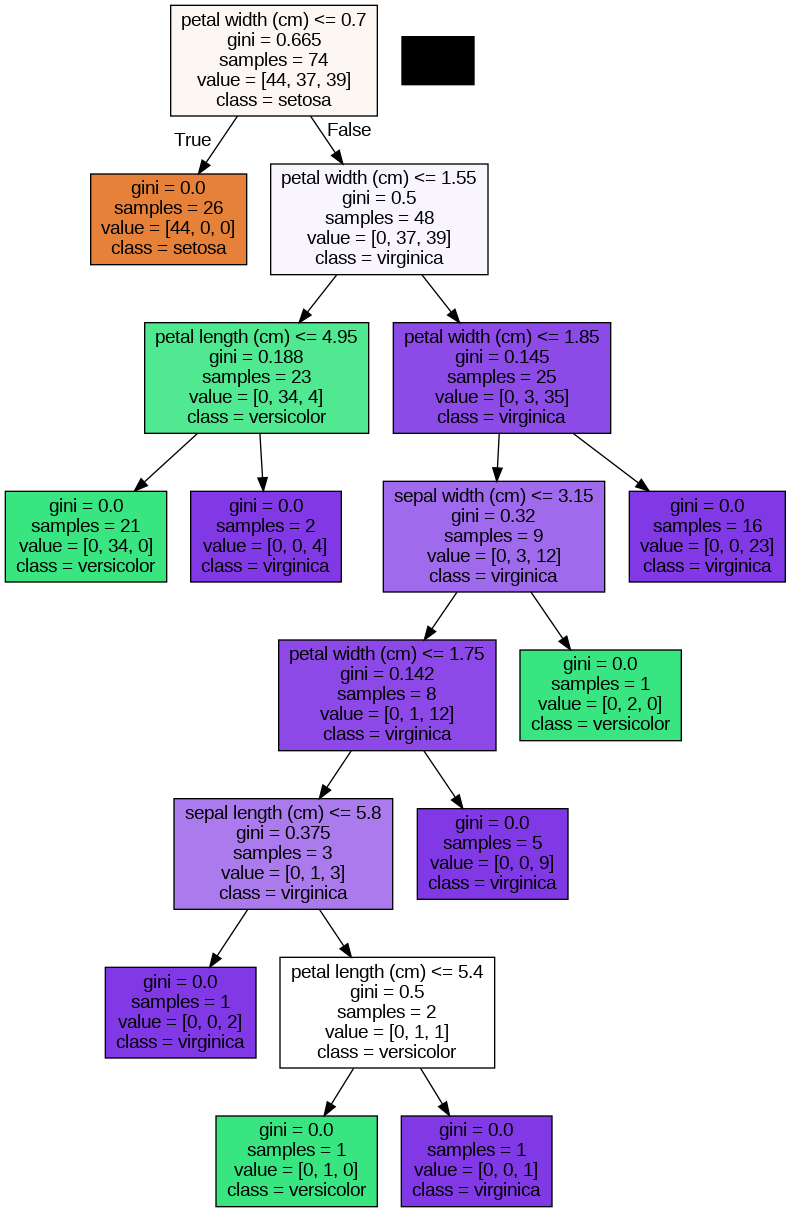

In [ ]:
from sklearn.tree import export_graphviz

# Select one tree from the Random Forest
tree_4b = rf_model_4b.estimators_[0]

# Generate Graphviz dot data
dot_data_rf_4b = export_graphviz(tree_4b, out_file=None,
                              feature_names=iris.feature_names,
                              class_names=iris.target_names,
                              filled=True)

# Convert dot data to a graph
graph_rf_4b = pydotplus.graph_from_dot_data(dot_data_rf_4b)


# Displaying the tree image
Image(graph_rf_4b.create_png())

## **LAB-4C**

In [ ]:
# Load dataset (adjust the file path as needed)
loans_4C = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_AND_ML/loan_data(in).csv")

# Display basic info
print(loans_4C.info())

# Check for missing values
print(loans_4C.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
None
credit.policy        0
purpose              0
int.rate    

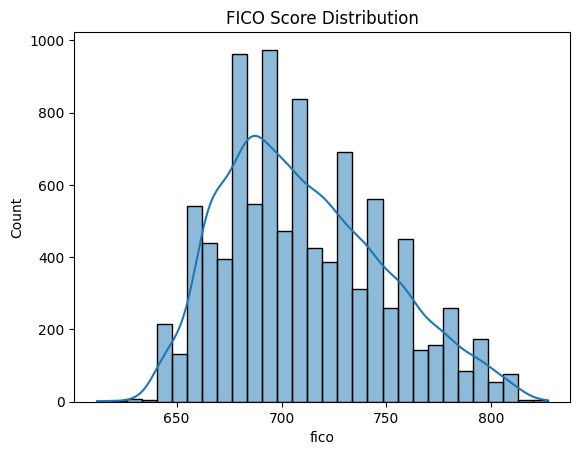

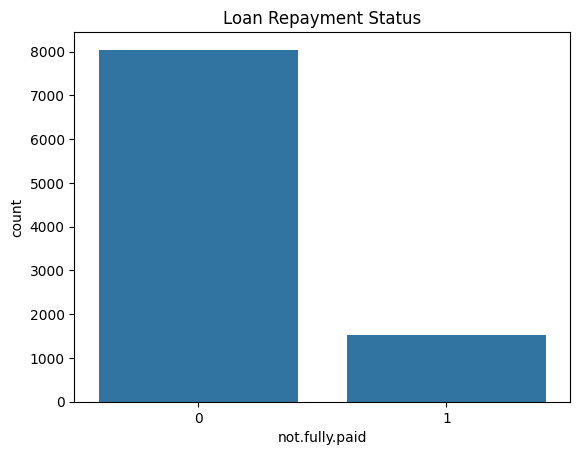

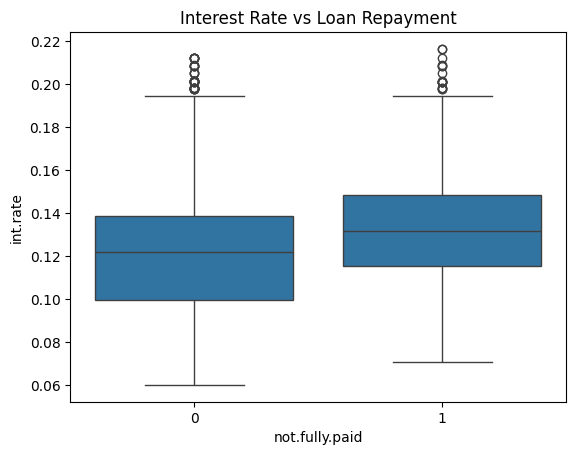

In [ ]:
# Histogram of FICO scores
sns.histplot(loans_4C['fico'], bins=30, kde=True)
plt.title('FICO Score Distribution')
plt.show()

# Countplot of 'not.fully.paid'
sns.countplot(x='not.fully.paid', data=loans_4C)
plt.title('Loan Repayment Status')
plt.show()

# Interest Rate vs. Not Fully Paid
sns.boxplot(x='not.fully.paid', y='int.rate', data=loans_4C)
plt.title('Interest Rate vs Loan Repayment')
plt.show()


In [ ]:
# Feature Engineering
cat_feats = ['purpose']
final_data = pd.get_dummies(loans_4C, columns=cat_feats, drop_first=True)

In [ ]:
# Train-Test Split
X_4c = final_data.drop('not.fully.paid', axis=1)
y_4c = final_data['not.fully.paid']
X_train_4c, X_test_4c, y_train_4c, y_test_4c = train_test_split(X_4c, y_4c, test_size=0.3, random_state=42)

In [ ]:
from sklearn.metrics import confusion_matrix

# Decision Tree for LendingClub
dtree = DecisionTreeClassifier()
dtree.fit(X_train_4c, y_train_4c)
y_pred_tree = dtree.predict(X_test_4c)
print(classification_report(y_test_4c, y_pred_tree))
print(confusion_matrix(y_test_4c, y_pred_tree))


              precision    recall  f1-score   support

           0       0.85      0.83      0.84      2408
           1       0.20      0.21      0.21       466

    accuracy                           0.73      2874
   macro avg       0.52      0.52      0.52      2874
weighted avg       0.74      0.73      0.74      2874

[[2009  399]
 [ 367   99]]


In [ ]:

# Random Forest for LendingClub
rfc_4c = RandomForestClassifier(n_estimators=100)
rfc_4c.fit(X_train_4c, y_train_4c)
y_pred_rf_4c = rfc_4c.predict(X_test_4c)
print(classification_report(y_test_4c, y_pred_rf_4c))


              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2408
           1       0.40      0.02      0.03       466

    accuracy                           0.84      2874
   macro avg       0.62      0.51      0.47      2874
weighted avg       0.77      0.84      0.77      2874

[[2396   12]
 [ 458    8]]


12. Now create a classification report from the results. Do you get anything strange or somesort of warning?

 Ans) The model predicts class 0 (fully paid) very well but performs poorly on class 1 (not fully paid).
The recall for class 1 in the Random Forest is only 0.02 (meaning it barely identifies actual defaults).
This suggests class imbalance—the dataset has significantly more fully paid loans (class 0) than defaulted loans (class 1), which skews the model

In [ ]:
print(confusion_matrix(y_test_4c, y_pred_rf_4c))

[[2396   12]
 [ 458    8]]


14) What performed better the random forest or the decision tree? Can a better featureengineering improve the results?

Ans)


1. What performed better the random forest or the decision tree?

*   Overall accuracy: Random Forest (0.84) > Decision Tree (0.73).
*   Ranndom Forest is overly biased toward predicting class 0, while the Decision Tree gives a more balanced classification.


2. Can a better featureengineering improve the results?


*   **Feature selection:** Remove redundant or weakly correlated features.
*  **Hyperparameter tuning:** Optimize max_depth, min_samples_split, and n_estimators for Random Forest.






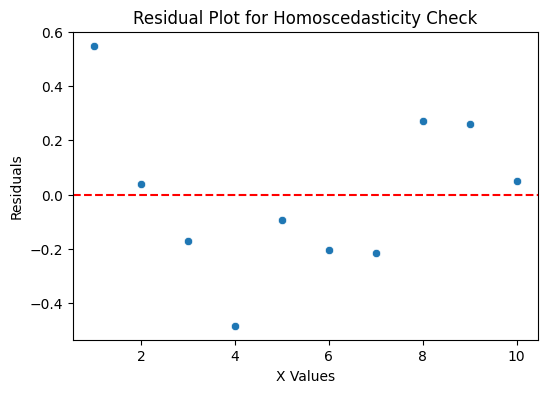

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Sample data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([2.1, 2.5, 3.2, 3.8, 5.1, 5.9, 6.8, 8.2, 9.1, 9.8])  # Linear relationship with some noise

# Fit Linear Regression
model = LinearRegression()
x_reshaped = x.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Compute Residuals
residuals = y - y_pred

# Plot Residuals
plt.figure(figsize=(6, 4))
sns.scatterplot(x=x, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')  # Reference line at zero
plt.xlabel("X Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Homoscedasticity Check")
plt.show()
